In [132]:
import pandas as pd
import numpy as np

data_df = pd.read_csv('Advertising.csv', index_col=0)

In [133]:
data_df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [134]:
x = data_df[['TV','radio']].to_numpy()
y = data_df[['sales']].to_numpy()

In [135]:
# adding 1 in arrays
x = np.concat((np.ones((x.shape[0], 1)), x), axis = 1)

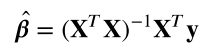

In [136]:
# Multiple Linear Regression 
first_term = np.linalg.inv(np.dot(x.T,x))
betas = first_term.dot(x.T).dot(y)

In [137]:
betas.flatten()

array([2.92109991, 0.04575482, 0.18799423])

In [138]:
# print(f'y = {betas[0]:.3f} + {betas[1]:.3f} x1 + {betas[2]:.3f} x2')

In [139]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

sse = lambda y_true, y_prod : np.sum(np.power((y_true, y_prod), 2))

In [140]:
x = data_df[['TV','radio']].to_numpy()
y = data_df[['sales']].to_numpy()

In [141]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 999)

In [142]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [143]:
y_predict = lin_reg.predict(x_test)

In [144]:
# sse =  sse(y_test, y_prod)
sse = np.sum(np.power((y_test - y_predict), 2))
sse.round(4)

np.float64(106.5115)

In [145]:
mean_squared_error(y_test, y_predict)

2.6627875158200003

In [146]:
mean_absolute_error(y_test, y_predict)

1.268229950045677

In [147]:
r2_score(y_test, y_predict)

0.8948652390616871

##### Problem with this R2 Coefficient

A higher R
2
 may look like a better model even when the new features are meaningless.

This can cause:

Overfitting
More complex models
Poor performance on new data

That is why Adjusted R
2
 is often preferred, because it penalizes unnecessary features.

### Adjusted R2 Coefficient

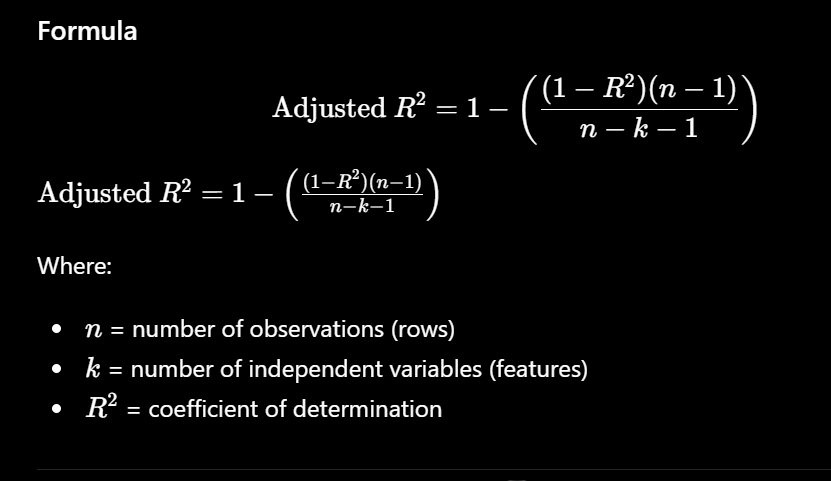

In [148]:
from sklearn.metrics import r2_score

def adjusted_r2(y_true, y_pred, d):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    
    return 1 - (1 - r2) * ((n - 1) / (n - d - 1))

In [149]:
# print('R2 Coef = ', r2_score(y_test, y_pred))
# print('Adjusted R2 = ', adjusted_r2(y_test, y_pred, d=3))